In [173]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

TRAIN_DATASET_DIR = "./learn_dataset_single_object"  # 学習: 単一物体
TEST_DATASET_DIR  = "./learn_dataset_fixed_angle"     # テスト: 2物体同時
TRAIN_META_CSV = os.path.join(TRAIN_DATASET_DIR, "metadata.csv")
TEST_META_CSV  = os.path.join(TEST_DATASET_DIR,  "metadata.csv")
MODEL_PATH = "./best_detector_agnostic.pt"

N_FIXED = 10

DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 16
EPOCHS     = 15
LR         = 1e-3

D_TOL = 2
R_TOL = 3

print("DEVICE:", DEVICE)
print("TRAIN_META_CSV exists:", os.path.exists(TRAIN_META_CSV))
print("TEST_META_CSV  exists:", os.path.exists(TEST_META_CSV))


DEVICE: cpu
TRAIN_META_CSV exists: True
TEST_META_CSV  exists: True


In [174]:
def Radar_setting():
    ###### symbol time & carrier frequency ######
    T_symbol = 5.575 * 1e-6              # symbol duration, with CP time
    T_OFDM = 5.2125 * 1e-6
    f_carrier = 28 * 1e+9
    Tc = 2.545*1e-9                      # sampling time

    ###### tx/rx ######
    N_ant = 16                       # the number of antennas
    # BW = 1.966080e+9                      # chirp bandwidth
    BW = 400*1e+6                    # chirp bandwidth
    BW_sub = BW/N_ant
    N_sample = int(np.floor(T_symbol/Tc))           # the number of samples of single chirp
    rx_sample = 813 + N_sample

    ###### Radar setting ######

    mu = BW_sub/T_symbol * 0.98
    l_speed = 299792458

    lam = l_speed/f_carrier
    env = cyclist_env(f_carrier, N_ant, BW, BW_sub, N_sample, rx_sample, Tc, mu, l_speed)
    return T_symbol,f_carrier,Tc,N_ant,BW,BW_sub,N_sample,rx_sample, mu, l_speed, lam, env

In [175]:
def MUSIC_method_improved(Y, N_ant, num_signals, frame_count):
    '''
    修正前
    Y_music = np.mean(Y, axis=0)
    R_yy = Y_music@np.conjugate(np.transpose(Y_music))
    '''
    # 修正後: 
    # チャープ軸(0)とサンプル軸(2)の両方を「スナップショット」として扱います。
    # (N_trans, N_ant, N_sample) -> (N_ant, N_trans * N_sample) に変形
    # これにより、N_trans(チャープ数)が増えるほど、スナップショット数が増え、
    # 共分散行列 R_yy の推定精度が向上します。
    N_trans, N_ant_data, N_sample = Y.shape
    # データを (アンテナ数 x 全サンプル数) の2次元行列に変形
    Y_music = Y.transpose(1, 0, 2).reshape(N_ant_data, -1)
    
    # 共分散行列の計算
    # (行列サイズは アンテナ数 x アンテナ数 のまま変わらないので計算負荷は軽微です)
    R_yy = (Y_music @ np.conjugate(Y_music.T)) / Y_music.shape[1]
    
    # 1.固有値分解
    eig_val, eig_vec = np.linalg.eig(R_yy)
    
    # 2.固有値をソートして雑音部分空間を取得
    idx = np.abs(eig_val).argsort()[::-1]
    # インデックスによって固有値と固有ベクトルの対応関係を維持しつつソート
    eig_val = eig_val[idx]
    eig_vec = eig_vec[:, idx]
    # 雑音部分空間Uを取得

    # num_signalsを固有値から推定?
    
    # デバッグ用
    num_signals = 5
    
    U = eig_vec[:, num_signals:]
    

    # 3.雑音部分空間とvalごとのステアリングベクトルの内積を計算
    resp = []
    argm = (np.arange(1800)-900)/100
    for val in argm:
        # ステアリングベクトルの計算
        stv = stevec(N_ant, val*np.pi/180)
        # 雑音部分空間との内積
        p = stv.T@U
        # L2ノルムの二乗を計算(pp^H)
        pp = p*np.conjugate(np.transpose(p))
        # A1は行列を1次元配列に変換するメソッド
        # respに逆数を追加
        # 分子は角度推定の上では不要なので省略している
        resp.append(1/(np.abs(pp)**2).A1)
    
    # 4.ピーク検出
    M = np.max(resp)
    
    # デバッグ用
    #MUSIC_method_Debug(eig_val, N_ant, num_signals, resp, argm, M, frame_count)
    
    est_ang = []
    # 三点比較によるピーク検出
    a, b = resp[0][0], resp[1][0]
    for i in range(1,len(argm)-1):
        c = resp[i+1][0]
        #if a < b and b > c and b > 0.2 * M:
        if a < b and b > c and b > 0.00001 * M:
            est_ang.append(argm[i])
        a, b = b, c
    return est_ang

In [176]:
class MultiTargetDataset(Dataset):
    def __init__(self, meta_df):
        self.meta_df = meta_df.reset_index(drop=True)

    def __len__(self):
        return len(self.meta_df)

    def __getitem__(self, idx):
        row = self.meta_df.iloc[idx]
        npz_path = row["file"]
        if not os.path.isabs(npz_path):
            npz_path = os.path.normpath(os.path.join(".", npz_path))

        x = load_all_rd_maps(npz_path)
        H, W = x.shape[1], x.shape[2]

        valid_cy = 1 if str(row["valid_cyclist"]).strip() in ("1", "True") else 0
        valid_ve = 1 if str(row["valid_vehicle"]).strip() in ("1", "True") else 0

        # 存在するターゲットのみガウスヒートマップ、不在は全ゼロ
        y_cy = make_gaussian_heatmap(H, W, int(row["cyclist_true_d_idx"]), int(row["cyclist_true_r_idx"])) if valid_cy else np.zeros((H, W), dtype=np.float32)
        y_ve = make_gaussian_heatmap(H, W, int(row["vehicle_true_d_idx"]), int(row["vehicle_true_r_idx"])) if valid_ve else np.zeros((H, W), dtype=np.float32)
        y = np.clip(y_cy + y_ve, 0.0, 1.0)[np.newaxis, :]  # (1, H, W)

        return {
            "x": torch.from_numpy(x).float(),
            "y": torch.from_numpy(y).float(),
            "cy_true_d": torch.tensor(int(row["cyclist_true_d_idx"]), dtype=torch.long),
            "cy_true_r": torch.tensor(int(row["cyclist_true_r_idx"]), dtype=torch.long),
            "ve_true_d": torch.tensor(int(row["vehicle_true_d_idx"]), dtype=torch.long),
            "ve_true_r": torch.tensor(int(row["vehicle_true_r_idx"]), dtype=torch.long),
            "valid_cy": torch.tensor(valid_cy, dtype=torch.long),
            "valid_ve": torch.tensor(valid_ve, dtype=torch.long),
        }


In [177]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels=32, dropout=0.1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
        )

    def forward(self, x):
        return self.block(x)

class RadarLightUNet(nn.Module):
    def __init__(self, in_channels=N_FIXED, out_channels=2, fixed_channels=32, dropout=0.1):
        super().__init__()

        self.encoders = nn.ModuleList([
            ConvBlock(in_channels, fixed_channels, dropout),
            ConvBlock(fixed_channels, fixed_channels, dropout),
            ConvBlock(fixed_channels, fixed_channels, dropout),
            ConvBlock(fixed_channels, fixed_channels, dropout),
        ])
        self.pools = nn.ModuleList([
            nn.MaxPool2d(2, 2) for _ in range(4)
        ])
        self.bottleneck = ConvBlock(fixed_channels, fixed_channels, dropout)
        self.upsamples = nn.ModuleList([
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
            for _ in range(4)
        ])
        self.decoders = nn.ModuleList([
            ConvBlock(fixed_channels * 2, fixed_channels, dropout)
            for _ in range(4)
        ])
        self.head = nn.Conv2d(fixed_channels, out_channels, kernel_size=1)

    def forward(self, x):
        skips = []
        for enc, pool in zip(self.encoders, self.pools):
            x = enc(x)
            skips.append(x)
            x = pool(x)

        x = self.bottleneck(x)

        for up, dec, skip in zip(self.upsamples, self.decoders, reversed(skips)):
            x = up(x)
            if x.shape[-2:] != skip.shape[-2:]:
                x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
            x = torch.cat([x, skip], dim=1)
            x = dec(x)

        return self.head(x)  # logits (B, 2, H, W)

In [178]:
# 学習用: 単一物体(280train+60val) + 2物体(200train) / テスト: 2物体(100test)
RANDOM_SEED = 42

# --- 単一物体データ ---
single_df = pd.read_csv(TRAIN_META_CSV)
single_df = single_df[single_df["valid_all"] == 1].reset_index(drop=True)
single_df = single_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
single_train_df = single_df.iloc[:280].reset_index(drop=True)
single_val_df   = single_df.iloc[280:340].reset_index(drop=True)

# --- 2物体データ ---
two_df = pd.read_csv(TEST_META_CSV)
two_df = two_df[two_df["valid_all"] == 1].reset_index(drop=True)
two_df = two_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
two_train_df = two_df.iloc[:200].reset_index(drop=True)
test_df      = two_df.iloc[200:].reset_index(drop=True)

# --- 結合 ---
train_df = pd.concat([single_train_df, two_train_df], ignore_index=True)
val_df   = single_val_df  # val は単一物体から

print(f"train: {len(train_df)}  (単一:{len(single_train_df)}, 2物体:{len(two_train_df)})")
print(f"val:   {len(val_df)}")
print(f"test:  {len(test_df)}")
display(train_df.head())


train: 480  (単一:280, 2物体:200)
val:   60
test:  100


,file,scenario,cyclist_true_d_idx,cyclist_true_r_idx,vehicle_true_d_idx,vehicle_true_r_idx,valid_cyclist,valid_vehicle,valid_all,source_index,sample_id,source_index_cyclist,source_index_vehicle,cyclist_true_range,cyclist_true_velocity,cyclist_true_angle_deg,vehicle_true_range,vehicle_true_velocity,vehicle_true_angle_deg
0,./learn_dataset_single_object\sample_00110.npz,cyclist_only,1,140,0,0,True,0,1,111.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,./learn_dataset_single_object\sample_00419.npz,vehicle_only,0,0,1,126,0,True,1,157.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,./learn_dataset_single_object\sample_00565.npz,vehicle_only,0,0,1,112,0,True,1,213.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,./learn_dataset_single_object\sample_00077.npz,cyclist_only,1,149,0,0,True,0,1,78.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,./learn_dataset_single_object\sample_00181.npz,cyclist_only,1,122,0,0,True,0,1,182.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [179]:
def evaluate_split(model, meta_df, batch_size=BATCH_SIZE, device=DEVICE):
    ds = SingleTargetDataset(meta_df.reset_index(drop=True))
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    loss, hit = run_epoch(model, loader, optimizer=None, device=device)
    return {
        "count": len(meta_df),
        "loss": loss,
        "hit_rate": hit,
    }

def evaluate_per_kind(model, meta_df, device=DEVICE):
    rows = []

    rows.append({
        "target_kind": "all",
        **evaluate_split(model, meta_df, device=device)
    })

    for target_kind in ["ped", "vehicle"]:
        sub_df = meta_df[meta_df["target_kind"] == target_kind].reset_index(drop=True)
        if len(sub_df) == 0:
            continue

        rows.append({
            "target_kind": target_kind,
            **evaluate_split(model, sub_df, device=device)
        })

    return pd.DataFrame(rows)

In [180]:
def make_gaussian_heatmap(H, W, center_d, center_r, sigma_d=3.0, sigma_r=1.0):
    d = np.arange(H, dtype=np.float32)[:, None]
    r = np.arange(W, dtype=np.float32)[None, :]
    heatmap = np.exp(
        -0.5 * (((d - center_d) / sigma_d) ** 2 + ((r - center_r) / sigma_r) ** 2)
    )
    return heatmap.astype(np.float32)

def load_all_rd_maps(npz_path):
    data = np.load(npz_path)
    rd_maps = data["rd_maps"]
    result = []
    for i in range(rd_maps.shape[0]):
        rd_mag = np.abs(rd_maps[i]).astype(np.float32)
        rd_db = 20.0 * np.log10(np.maximum(rd_mag, 1e-12))
        result.append(rd_db)
    return np.stack(result, axis=0)

def decode_peaks_from_logits(logits, threshold=0.8):
    """1chヒートマップから上位2ピークを検出して返す [(d1,r1,conf1),(d2,r2,conf2)]"""
    prob = torch.sigmoid(logits)[0, 0]  # (H, W)
    H, W = prob.shape
    p = prob.clone()
    results = []
    while True:
        flat_idx = torch.argmax(p).item()
        d_idx = flat_idx // W
        r_idx = flat_idx % W
        conf = float(prob[d_idx, r_idx].item())
        if conf < threshold:
            break
        results.append((d_idx, r_idx, conf))
        d0, d1 = max(0, d_idx-3), min(H, d_idx+4)
        r0, r1 = max(0, r_idx-1), min(W, r_idx+2)
        p[d0:d1, r0:r1] = 0.0
    return results

def compute_hit(pred_d, pred_r, true_d, true_r, d_tol=D_TOL, r_tol=R_TOL):
    return (abs(pred_d - true_d) <= d_tol) and (abs(pred_r - true_r) <= r_tol)


In [181]:
def bce_loss_from_logits(logits, targets):
    return F.binary_cross_entropy_with_logits(logits, targets)

def dice_loss_from_logits(logits, targets, eps=1e-6):
    probs = torch.sigmoid(logits)
    num = 2 * (probs * targets).sum(dim=(2, 3))
    den = probs.sum(dim=(2, 3)) + targets.sum(dim=(2, 3)) + eps
    return (1 - num / den).mean()

def compute_loss(logits, targets):
    return bce_loss_from_logits(logits, targets) + dice_loss_from_logits(logits, targets)

def match_peaks_to_targets(peaks, cy_true_d, cy_true_r, ve_true_d, ve_true_r):
    import itertools
    if len(peaks) == 0:
        return (-1, -1), (-1, -1)
    if len(peaks) == 1:
        p = peaks[0][:2]
        cy_dist = (p[0]-cy_true_d)**2 + (p[1]-cy_true_r)**2
        ve_dist = (p[0]-ve_true_d)**2 + (p[1]-ve_true_r)**2
        if cy_dist <= ve_dist:
            return p, (-1, -1)
        else:
            return (-1, -1), p
    best_cy, best_ve = peaks[0][:2], peaks[1][:2]
    best_cost = float('inf')
    for p1, p2 in itertools.permutations(peaks[:2]):
        cost = ((p1[0]-cy_true_d)**2 + (p1[1]-cy_true_r)**2 +
                (p2[0]-ve_true_d)**2 + (p2[1]-ve_true_r)**2)
        if cost < best_cost:
            best_cost = cost
            best_cy, best_ve = p1[:2], p2[:2]
    return best_cy, best_ve

def run_epoch(model, loader, optimizer=None, device='cpu'):
    train_mode = optimizer is not None
    model.train(train_mode)

    total_loss = 0.0
    cy_hits, cy_total = 0, 0
    ve_hits, ve_total = 0, 0

    for batch in loader:
        x = batch['x'].to(device)
        y = batch['y'].to(device)
        cy_true_d = batch['cy_true_d'].cpu().numpy()
        cy_true_r = batch['cy_true_r'].cpu().numpy()
        ve_true_d = batch['ve_true_d'].cpu().numpy()
        ve_true_r = batch['ve_true_r'].cpu().numpy()
        valid_cy  = batch['valid_cy'].cpu().numpy()
        valid_ve  = batch['valid_ve'].cpu().numpy()

        if train_mode:
            optimizer.zero_grad()

        logits = model(x)
        loss = compute_loss(logits, y)

        if train_mode:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * x.size(0)

        for i in range(x.size(0)):
            peaks = decode_peaks_from_logits(logits[i:i+1].detach().cpu())
            (cy_d, cy_r), (ve_d, ve_r) = match_peaks_to_targets(
                peaks, int(cy_true_d[i]), int(cy_true_r[i]),
                int(ve_true_d[i]), int(ve_true_r[i])
            )
            if valid_cy[i]:
                cy_hits  += int(compute_hit(cy_d, cy_r, int(cy_true_d[i]), int(cy_true_r[i])))
                cy_total += 1
            if valid_ve[i]:
                ve_hits  += int(compute_hit(ve_d, ve_r, int(ve_true_d[i]), int(ve_true_r[i])))
                ve_total += 1

    n = len(loader.dataset)
    mean_loss   = total_loss / max(n, 1)
    cy_hit_rate = cy_hits / max(cy_total, 1)
    ve_hit_rate = ve_hits / max(ve_total, 1)
    return mean_loss, cy_hit_rate, ve_hit_rate

In [182]:
train_ds = MultiTargetDataset(train_df)
val_ds   = MultiTargetDataset(val_df)
test_ds  = MultiTargetDataset(test_df)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

model = RadarLightUNet(in_channels=N_FIXED, out_channels=1).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

best_val = float("inf")
history = []

for epoch in range(EPOCHS):
    train_loss, train_cy_hit, train_ve_hit = run_epoch(model, train_loader, optimizer=optimizer, device=DEVICE)
    val_loss,   val_cy_hit,   val_ve_hit   = run_epoch(model, val_loader,   optimizer=None,      device=DEVICE)

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_cy_hit": train_cy_hit,
        "train_ve_hit": train_ve_hit,
        "val_loss": val_loss,
        "val_cy_hit": val_cy_hit,
        "val_ve_hit": val_ve_hit,
    })

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), MODEL_PATH)

    print(
        f"epoch={epoch+1:02d} "
        f"train_loss={train_loss:.4f} cy={train_cy_hit:.3f} ve={train_ve_hit:.3f} | "
        f"val_loss={val_loss:.4f}   cy={val_cy_hit:.3f} ve={val_ve_hit:.3f}"
    )

print("best model saved to:", MODEL_PATH)
hist_df = pd.DataFrame(history)
display(hist_df.tail())

epoch=01 train_loss=1.0102 cy=0.000 ve=0.000 | val_loss=0.9681   cy=0.000 ve=0.000
epoch=02 train_loss=0.8753 cy=0.017 ve=0.000 | val_loss=0.7416   cy=0.577 ve=0.000
epoch=03 train_loss=0.6643 cy=0.676 ve=0.204 | val_loss=0.6573   cy=0.269 ve=0.824
epoch=04 train_loss=0.5984 cy=0.737 ve=0.575 | val_loss=0.5661   cy=0.385 ve=0.559
epoch=05 train_loss=0.5171 cy=0.751 ve=0.722 | val_loss=0.4651   cy=1.000 ve=0.588
epoch=06 train_loss=0.4544 cy=0.934 ve=0.862 | val_loss=0.3799   cy=1.000 ve=1.000
epoch=07 train_loss=0.3953 cy=0.957 ve=0.919 | val_loss=0.3598   cy=1.000 ve=1.000
epoch=08 train_loss=0.3740 cy=0.965 ve=0.964 | val_loss=0.3505   cy=0.923 ve=1.000
epoch=09 train_loss=0.3660 cy=0.951 ve=0.958 | val_loss=0.3432   cy=1.000 ve=1.000
epoch=10 train_loss=0.3576 cy=0.957 ve=0.964 | val_loss=0.3432   cy=1.000 ve=1.000
epoch=11 train_loss=0.3569 cy=0.925 ve=0.919 | val_loss=0.3426   cy=0.923 ve=1.000
epoch=12 train_loss=0.3497 cy=0.893 ve=0.928 | val_loss=0.3373   cy=0.500 ve=1.000
epoc

,epoch,train_loss,train_cy_hit,train_ve_hit,val_loss,val_cy_hit,val_ve_hit
10,11,0.356945,0.924855,0.919162,0.342585,0.923077,1.000000
11,12,0.349739,0.893064,0.928144,0.337264,0.500000,1.000000
12,13,0.348230,0.858382,0.931138,0.338576,0.538462,1.000000
13,14,0.347064,0.846821,0.925150,0.338879,0.730769,1.000000
14,15,0.347072,0.890173,0.940120,0.342148,0.692308,0.617647


In [183]:
best_model = RadarLightUNet(in_channels=N_FIXED, out_channels=1).to(DEVICE)
best_model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
best_model.eval()

test_loss, test_cy_hit, test_ve_hit = run_epoch(best_model, test_loader, optimizer=None, device=DEVICE)
print(f"test_loss={test_loss:.4f}  cyclist_hit={test_cy_hit:.3f}  vehicle_hit={test_ve_hit:.3f}")

test_loss=0.3589  cyclist_hit=1.000  vehicle_hit=0.920


=== sample 0 ===
[detection 1] d=2, r=124, conf=1.000
[detection 2] d=1, r=167, conf=1.000
[detection 3] d=5, r=167, conf=0.833
[true] cyclist=(1,167)  vehicle=(1,124)


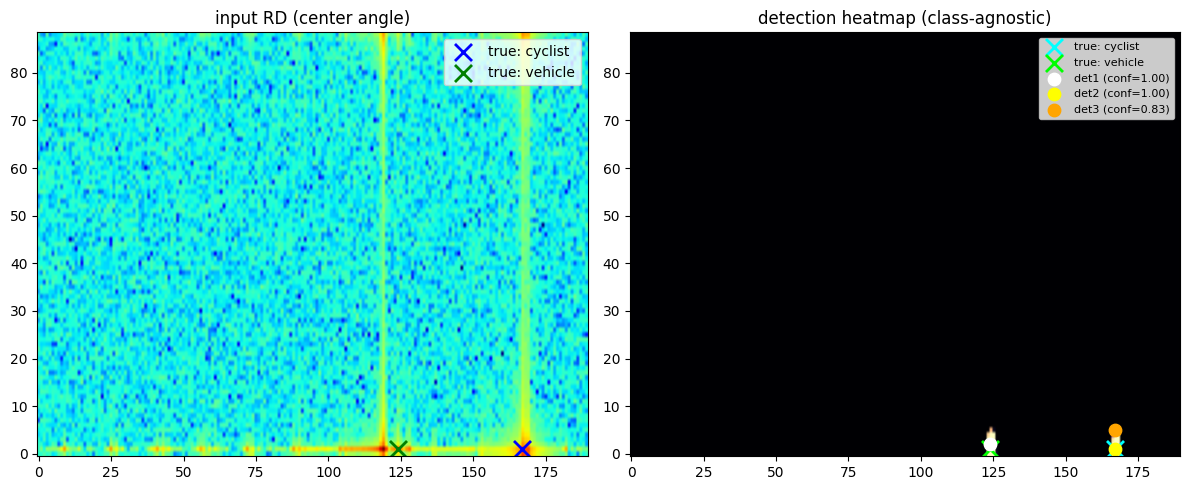

=== sample 1 ===
[detection 1] d=2, r=144, conf=1.000
[detection 2] d=1, r=137, conf=1.000
[true] cyclist=(1,137)  vehicle=(1,144)


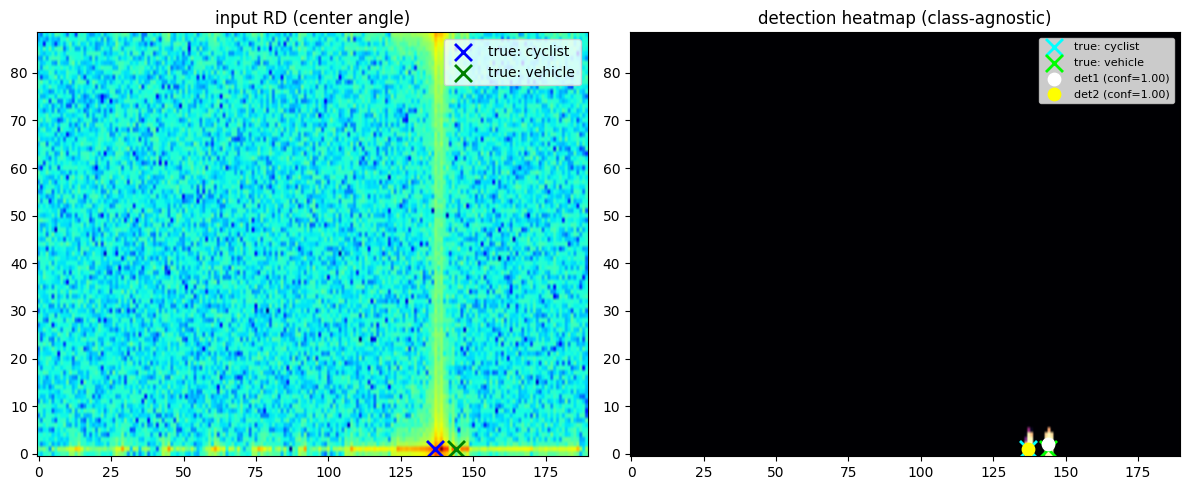

In [184]:
def show_prediction(sample_idx=0):
    row = test_df.iloc[sample_idx]
    npz_path = row["file"]
    if not os.path.isabs(npz_path):
        npz_path = os.path.normpath(os.path.join(".", npz_path))

    x = load_all_rd_maps(npz_path)
    x_tensor = torch.from_numpy(x).unsqueeze(0).float().to(DEVICE)

    with torch.no_grad():
        logits = best_model(x_tensor)

    peaks = decode_peaks_from_logits(logits.cpu())

    cy_true_d = int(row["cyclist_true_d_idx"])
    cy_true_r = int(row["cyclist_true_r_idx"])
    ve_true_d = int(row["vehicle_true_d_idx"])
    ve_true_r = int(row["vehicle_true_r_idx"])

    print(f"=== sample {sample_idx} ===")
    for j, (pd, pr, pc) in enumerate(peaks):
        print(f"[detection {j+1}] d={pd}, r={pr}, conf={pc:.3f}")
    print(f"[true] cyclist=({cy_true_d},{cy_true_r})  vehicle=({ve_true_d},{ve_true_r})")

    rd_db   = x[N_FIXED // 2]
    heatmap = torch.sigmoid(logits)[0, 0].cpu().numpy()
    colors  = ["white", "yellow", "orange", "red"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].imshow(rd_db, aspect="auto", origin="lower", cmap="jet")
    axes[0].scatter([cy_true_r], [cy_true_d], c="blue",  marker="x", s=150, linewidths=2, label="true: cyclist")
    axes[0].scatter([ve_true_r], [ve_true_d], c="green", marker="x", s=150, linewidths=2, label="true: vehicle")
    axes[0].set_title("input RD (center angle)")
    axes[0].legend()

    axes[1].imshow(heatmap, aspect="auto", origin="lower", cmap="magma")
    axes[1].scatter([cy_true_r], [cy_true_d], c="cyan",  marker="x", s=150, linewidths=2, label="true: cyclist")
    axes[1].scatter([ve_true_r], [ve_true_d], c="lime",  marker="x", s=150, linewidths=2, label="true: vehicle")
    for j, (pd, pr, pc) in enumerate(peaks):
        axes[1].scatter([pr], [pd], c=colors[j % len(colors)], marker="o", s=80, label=f"det{j+1} (conf={pc:.2f})")
    axes[1].set_title("detection heatmap (class-agnostic)")
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

show_prediction(sample_idx=0)
show_prediction(sample_idx=1)


In [185]:
def show_failure_pattern(sample_idx, title=""):
    row = test_df.iloc[sample_idx]
    npz_path = row["file"]
    if not os.path.isabs(npz_path):
        npz_path = os.path.normpath(os.path.join(".", npz_path))
    x = load_all_rd_maps(npz_path)
    x_tensor = torch.from_numpy(x).unsqueeze(0).float().to(DEVICE)
    with torch.no_grad():
        logits = best_model(x_tensor)
    prob = torch.sigmoid(logits)[0, 0].cpu().numpy()  # threshold なし

    cy_r = int(row['cyclist_true_r_idx'])
    ve_r = int(row['vehicle_true_r_idx'])
    cy_d = int(row['cyclist_true_d_idx'])
    ve_d = int(row['vehicle_true_d_idx'])
    rd_center = x[N_FIXED // 2]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"{title}  [sample {sample_idx}]  |cy_r - ve_r| = {abs(cy_r - ve_r)} bins")

    axes[0].imshow(rd_center, aspect='auto', origin='lower', cmap='jet')
    axes[0].plot(cy_r, cy_d, 'bx', ms=10, mew=2, label='true: cyclist')
    axes[0].plot(ve_r, ve_d, 'gx', ms=10, mew=2, label='true: vehicle')
    axes[0].set_title("input RD (center angle)")
    axes[0].legend()

    im = axes[1].imshow(prob, aspect='auto', origin='lower', cmap='hot', vmin=0, vmax=1)
    axes[1].plot(cy_r, cy_d, 'cx', ms=10, mew=2, label='true: cyclist')
    axes[1].plot(ve_r, ve_d, 'gx', ms=10, mew=2, label='true: vehicle')
    axes[1].set_title("heatmap (no threshold)")
    axes[1].legend()
    plt.colorbar(im, ax=axes[1])
    plt.tight_layout()
    plt.show()

In [186]:
def collect_predictions(meta_df):
    rows = []
    for i in range(len(meta_df)):
        row = meta_df.iloc[i]
        npz_path = row['file']
        if not os.path.isabs(npz_path):
            npz_path = os.path.normpath(os.path.join('.', npz_path))
        x = load_all_rd_maps(npz_path)
        x_tensor = torch.from_numpy(x).unsqueeze(0).float().to(DEVICE)
        with torch.no_grad():
            logits = best_model(x_tensor)
        peaks = decode_peaks_from_logits(logits.cpu())

        # ピーク数が可変なのでデフォルト値-1で埋める
        det1_d, det1_r, det1_conf = peaks[0] if len(peaks) > 0 else (-1, -1, 0.0)
        det2_d, det2_r, det2_conf = peaks[1] if len(peaks) > 1 else (-1, -1, 0.0)

        cy_true_d = int(row['cyclist_true_d_idx'])
        cy_true_r = int(row['cyclist_true_r_idx'])
        ve_true_d = int(row['vehicle_true_d_idx'])
        ve_true_r = int(row['vehicle_true_r_idx'])

        (cy_d, cy_r), (ve_d, ve_r) = match_peaks_to_targets(
            peaks, cy_true_d, cy_true_r, ve_true_d, ve_true_r
        )

        rows.append({
            'sample_idx': i,
            'file': row['file'],
            'det1_d': det1_d, 'det1_r': det1_r, 'det1_conf': det1_conf,
            'det2_d': det2_d, 'det2_r': det2_r, 'det2_conf': det2_conf,
            'cy_true_d': cy_true_d, 'cy_true_r': cy_true_r,
            've_true_d': ve_true_d, 've_true_r': ve_true_r,
            'cy_d_err': cy_d - cy_true_d, 'cy_r_err': cy_r - cy_true_r,
            've_d_err': ve_d - ve_true_d, 've_r_err': ve_r - ve_true_r,
            'cy_hit': compute_hit(cy_d, cy_r, cy_true_d, cy_true_r),
            've_hit': compute_hit(ve_d, ve_r, ve_true_d, ve_true_r),
        })
    return pd.DataFrame(rows)

In [187]:
pred_df = collect_predictions(test_df)

print("=== hit rate ===")
print(f"cyclist正解への検出率: {pred_df['cy_hit'].mean():.3f}")
print(f"vehicle正解への検出率: {pred_df['ve_hit'].mean():.3f}")

print("=== cyclist 失敗例 ===")
display(pred_df[pred_df["cy_hit"] == False][["cy_true_d","cy_true_r","det1_d","det1_r","det2_d","det2_r"]].head())
print("=== vehicle 失敗例 ===")
display(pred_df[pred_df["ve_hit"] == False][["ve_true_d","ve_true_r","det1_d","det1_r","det2_d","det2_r"]].head())


=== hit rate ===
cyclist正解への検出率: 1.000
vehicle正解への検出率: 0.920
=== cyclist 失敗例 ===


,cy_true_d,cy_true_r,det1_d,det1_r,det2_d,det2_r


=== vehicle 失敗例 ===


,ve_true_d,ve_true_r,det1_d,det1_r,det2_d,det2_r
11,1,96,2,95,-1,-1
44,1,113,1,113,5,113
51,1,157,2,156,-1,-1
57,1,151,2,149,-1,-1
68,1,92,2,95,-1,-1


r_diff (bins) ごとの失敗集計:
 r_diff   total   ve_fail   ve_fail%   cy_fail   cy_fail%
------------------------------------------------------------
      0       1         1     100.0%         0       0.0%
      1       1         0       0.0%         0       0.0%
      2       3         3     100.0%         0       0.0%
      3       2         2     100.0%         0       0.0%
      4       3         0       0.0%         0       0.0%
      5       2         0       0.0%         0       0.0%
      6       3         0       0.0%         0       0.0%
      7       3         0       0.0%         0       0.0%
      8       4         0       0.0%         0       0.0%
      9       3         0       0.0%         0       0.0%
     10       2         0       0.0%         0       0.0%
     11       3         0       0.0%         0       0.0%
     12       3         0       0.0%         0       0.0%
     13       4         0       0.0%         0       0.0%
     14       2         1      50.0%         0

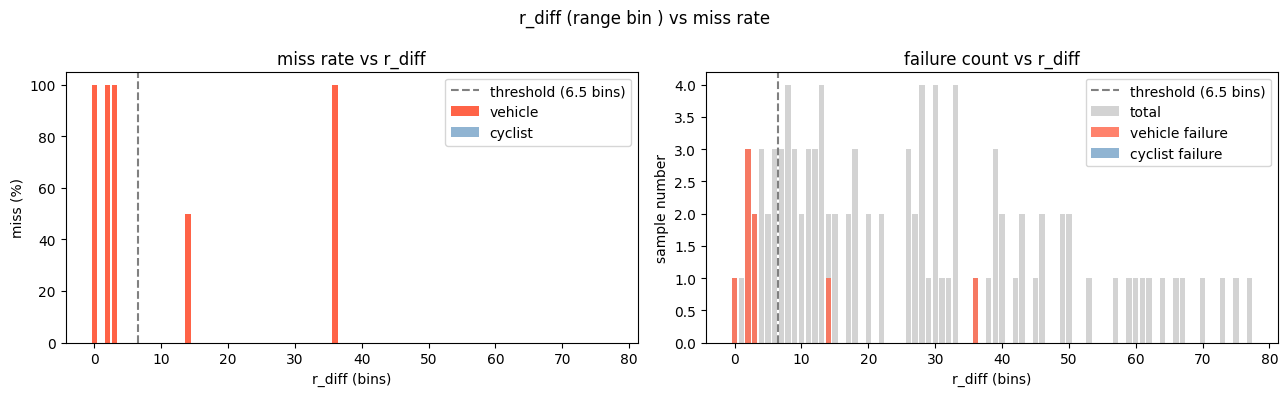

In [188]:
# === 近接失敗ケース: r_diff ごとの失敗数・失敗率 ===
import matplotlib.pyplot as plt
import numpy as np

# 全サンプルにr_diffを付加
pred_df2 = pred_df.copy()
pred_df2['r_diff'] = abs(pred_df2['cy_true_r'] - pred_df2['ve_true_r'])

# r_diff ごとに集計
summary = []
for d in sorted(pred_df2['r_diff'].unique()):
    sub = pred_df2[pred_df2['r_diff'] == d]
    total = len(sub)
    ve_fail = (sub['ve_hit'] == 0).sum()
    cy_fail = (sub['cy_hit'] == 0).sum()
    summary.append({'r_diff': d, 'total': total,
                     've_fail': ve_fail, 'cy_fail': cy_fail,
                     've_fail_rate': ve_fail / total,
                     'cy_fail_rate': cy_fail / total})

import pandas as pd
summary_df = pd.DataFrame(summary)

print('r_diff (bins) ごとの失敗集計:')
print(f'{"r_diff":>7}  {"total":>6}  {"ve_fail":>8}  {"ve_fail%":>9}  {"cy_fail":>8}  {"cy_fail%":>9}')
print('-' * 60)
for _, row in summary_df.iterrows():
    print(f"{int(row['r_diff']):>7}  {int(row['total']):>6}  {int(row['ve_fail']):>8}  {row['ve_fail_rate']*100:>8.1f}%  {int(row['cy_fail']):>8}  {row['cy_fail_rate']*100:>8.1f}%")

# 可視化
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('r_diff (range bin ) vs miss rate')

diffs = summary_df['r_diff'].values
axes[0].bar(diffs, summary_df['ve_fail_rate'] * 100, color='tomato', label='vehicle')
axes[0].bar(diffs, summary_df['cy_fail_rate'] * 100, color='steelblue', alpha=0.6, label='cyclist')
axes[0].axvline(6.5, color='gray', linestyle='--', label='threshold (6.5 bins)')
axes[0].set_xlabel('r_diff (bins)')
axes[0].set_ylabel('miss (%)')
axes[0].set_title('miss rate vs r_diff')
axes[0].legend()

axes[1].bar(diffs, summary_df['total'], color='lightgray', label='total')
axes[1].bar(diffs, summary_df['ve_fail'], color='tomato', alpha=0.8, label='vehicle failure')
axes[1].bar(diffs, summary_df['cy_fail'], color='steelblue', alpha=0.6, label='cyclist failure')
axes[1].axvline(6.5, color='gray', linestyle='--', label='threshold (6.5 bins)')
axes[1].set_xlabel('r_diff (bins)')
axes[1].set_ylabel('sample number')
axes[1].set_title('failure count vs r_diff')
axes[1].legend()

plt.tight_layout()
plt.show()


 r_diff  total    n=0    n=1    n=2   cy_min_dr   ve_min_dr
------------------------------------------------------------
      0      1      0      0      1         0.0         0.0
      1      1      0      0      1         0.0         1.0
      2      3      0      3      0         1.0         1.0
      3      2      0      2      0         0.5         2.5
      4      3      0      0      3         0.0         0.0
      5      2      0      0      2         0.0         1.0
      6      3      0      0      3         0.0         0.0
      7      3      0      0      3         0.0         0.0
      8      4      0      0      4         0.0         0.0
      9      3      0      0      3         1.0         0.0
     10      2      0      0      2         0.0         0.5
     11      3      0      0      3         0.0         0.0
     12      3      0      0      3         0.0         0.0
     13      4      0      0      4         0.0         0.0
     14      2      0      1      1    

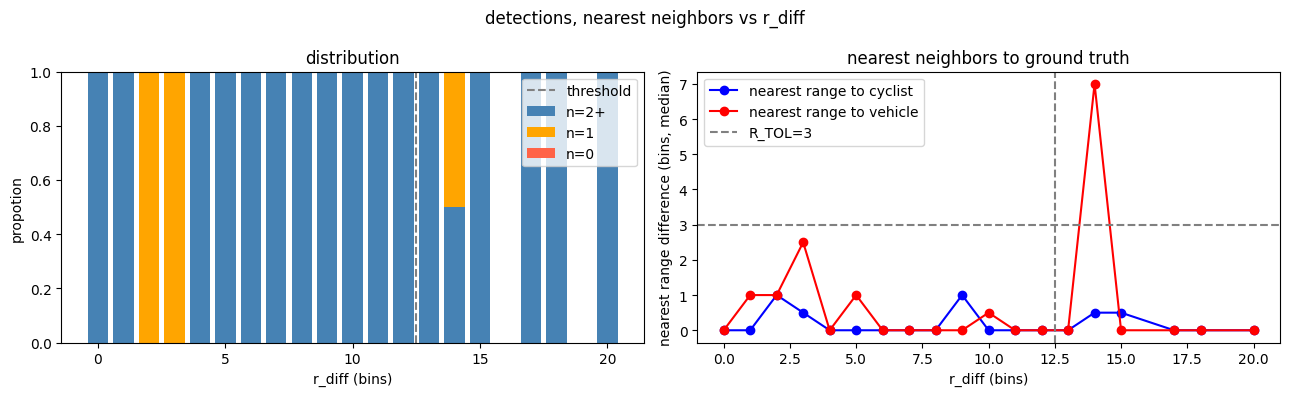

In [189]:
# === 検出数・最近傍距離ベースの分析 ===
import torch, numpy as np, matplotlib.pyplot as plt

pred_df['r_diff'] = abs(pred_df['cy_true_r'] - pred_df['ve_true_r'])

rows = []
for _, row in pred_df.iterrows():
    idx = int(row['sample_idx'])
    npz_path = test_df.iloc[idx]['file']
    if not os.path.isabs(npz_path):
        npz_path = os.path.normpath(os.path.join('.', npz_path))
    x = load_all_rd_maps(npz_path)
    x_tensor = torch.from_numpy(x).unsqueeze(0).float().to(DEVICE)
    with torch.no_grad():
        logits = best_model(x_tensor)
    peaks = decode_peaks_from_logits(logits.cpu())

    cy_r = int(row['cy_true_r']); cy_d = int(row['cy_true_d'])
    ve_r = int(row['ve_true_r']); ve_d = int(row['ve_true_d'])

    # 各真値への最近傍 range 誤差
    if len(peaks) > 0:
        cy_min_dr = min(abs(p[1] - cy_r) for p in peaks)
        ve_min_dr = min(abs(p[1] - ve_r) for p in peaks)
    else:
        cy_min_dr = ve_min_dr = 999

    rows.append({
        'r_diff': int(row['r_diff']),
        'n_peaks': len(peaks),
        'cy_min_dr': cy_min_dr,
        've_min_dr': ve_min_dr,
    })

det_df = pd.DataFrame(rows)

# r_diff ごとに集計 (失敗ゾーンのみ)
print(f"{'r_diff':>7}  {'total':>5}  {'n=0':>5}  {'n=1':>5}  {'n=2':>5}  {'cy_min_dr':>10}  {'ve_min_dr':>10}")
print("-" * 60)
for d in sorted(det_df['r_diff'].unique()):
    sub = det_df[det_df['r_diff'] == d]
    if d > 15:
        continue
    n0 = (sub['n_peaks'] == 0).sum()
    n1 = (sub['n_peaks'] == 1).sum()
    n2 = (sub['n_peaks'] >= 2).sum()
    cy_med = sub['cy_min_dr'].median()
    ve_med = sub['ve_min_dr'].median()
    print(f"{d:>7}  {len(sub):>5}  {n0:>5}  {n1:>5}  {n2:>5}  {cy_med:>10.1f}  {ve_med:>10.1f}")

# 可視化
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('detections, nearest neighbors vs r_diff')

# 左: 検出数の割合
diffs = sorted(det_df['r_diff'].unique())
diffs_plot = [d for d in diffs if d <= 20]
n0_rate = [((det_df[det_df['r_diff']==d]['n_peaks']==0).sum()/len(det_df[det_df['r_diff']==d])) for d in diffs_plot]
n1_rate = [((det_df[det_df['r_diff']==d]['n_peaks']==1).sum()/len(det_df[det_df['r_diff']==d])) for d in diffs_plot]
n2_rate = [((det_df[det_df['r_diff']==d]['n_peaks']>=2).sum()/len(det_df[det_df['r_diff']==d])) for d in diffs_plot]
axes[0].bar(diffs_plot, n2_rate, label='n=2+', color='steelblue')
axes[0].bar(diffs_plot, n1_rate, bottom=n2_rate, label='n=1', color='orange')
axes[0].bar(diffs_plot, n0_rate, bottom=[a+b for a,b in zip(n2_rate,n1_rate)], label='n=0', color='tomato')
axes[0].axvline(12.5, color='gray', linestyle='--', label='threshold')
axes[0].set_xlabel('r_diff (bins)'); axes[0].set_ylabel('propotion')
axes[0].set_title('distribution'); axes[0].legend()

# 右: 真値への最近傍距離の中央値
cy_meds = [det_df[det_df['r_diff']==d]['cy_min_dr'].median() for d in diffs_plot]
ve_meds = [det_df[det_df['r_diff']==d]['ve_min_dr'].median() for d in diffs_plot]
axes[1].plot(diffs_plot, cy_meds, 'b-o', label='nearest range to cyclist')
axes[1].plot(diffs_plot, ve_meds, 'r-o', label='nearest range to vehicle')
axes[1].axhline(3, color='gray', linestyle='--', label='R_TOL=3')
axes[1].axvline(12.5, color='gray', linestyle='--')
axes[1].set_xlabel('r_diff (bins)'); axes[1].set_ylabel('nearest range difference (bins, median)')
axes[1].set_title('nearest neighbors to ground truth'); axes[1].legend()

plt.tight_layout()
plt.show()


In [190]:
# hitサンプルのみで誤差を計算
cy_hit_df = pred_df[pred_df['cy_hit'] == 1]
ve_hit_df = pred_df[pred_df['ve_hit'] == 1]

print("=== 誤差統計 (hit samples only) ===")
err_cols = pd.DataFrame({
    'cy_d_err': cy_hit_df['cy_d_err'],
    'cy_r_err': cy_hit_df['cy_r_err'],
    've_d_err': ve_hit_df['ve_d_err'],
    've_r_err': ve_hit_df['ve_r_err'],
})
print(err_cols.describe().loc[['mean','std','max','min']])


=== 誤差統計 (hit samples only) ===
      cy_d_err  cy_r_err  ve_d_err  ve_r_err
mean  0.710000  0.110000  0.934783 -0.119565
std   0.477684  0.399368  0.248262  0.510169
max   1.000000  1.000000  1.000000  1.000000
min  -1.000000 -1.000000  0.000000 -3.000000


scenario: cyclist_only
det1: d=2, r=168, conf=1.0000


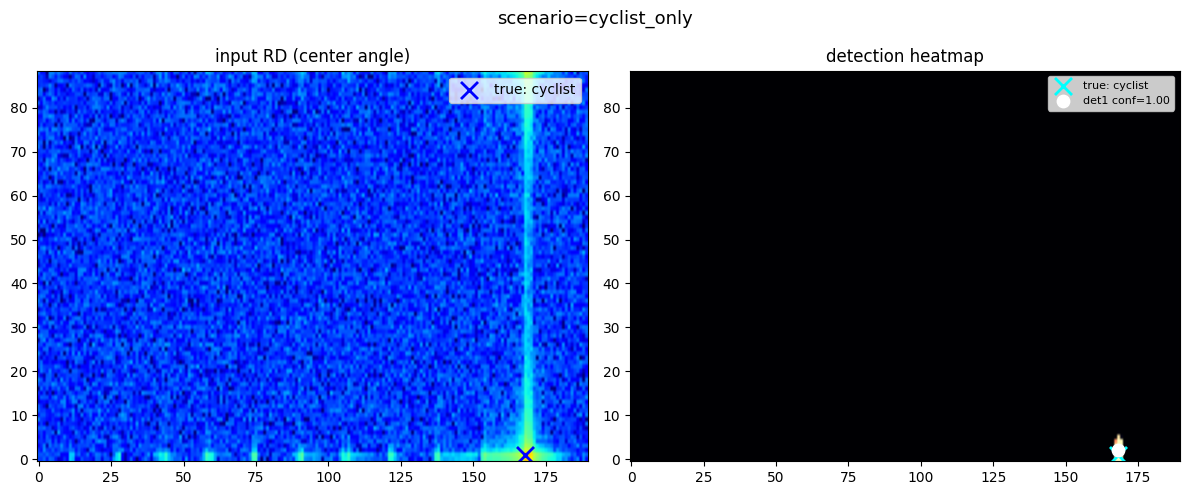

scenario: vehicle_only
det1: d=2, r=99, conf=1.0000
det2: d=1, r=101, conf=0.8554


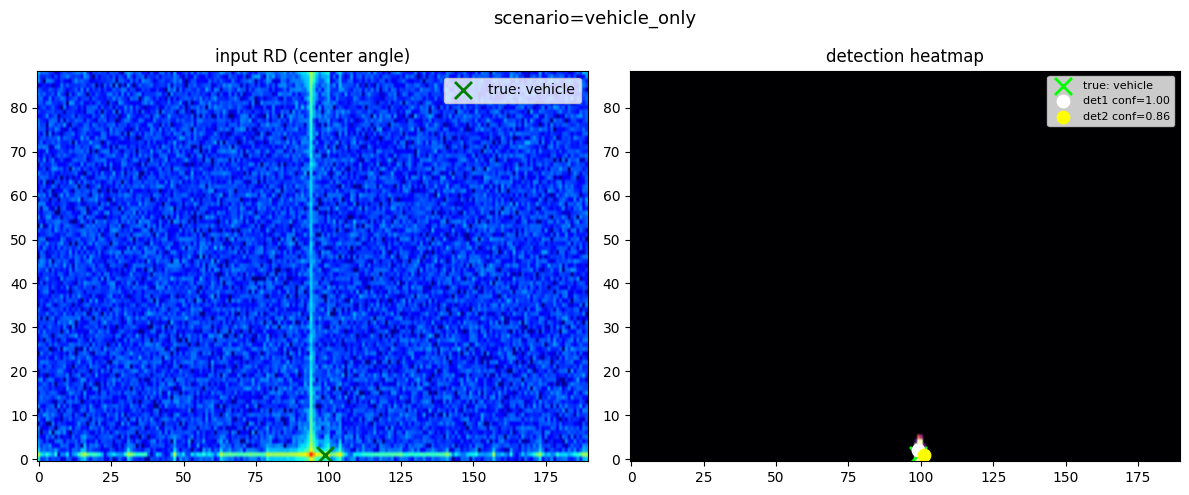

In [191]:
# === 単一物体サンプルでのチャンネル抑制確認 ===
# cyclist_only → ch0にピーク・ch1がフラット になるか
# vehicle_only → ch0がフラット・ch1にピーク になるか

def show_channel_suppression(scenario, sample_idx=0):
    single_df = pd.read_csv("./learn_dataset_single_object/metadata.csv")
    single_df = single_df[single_df["scenario"] == scenario].reset_index(drop=True)
    row = single_df.iloc[sample_idx]

    npz_path = row["file"]
    if not os.path.isabs(npz_path):
        npz_path = os.path.normpath(os.path.join(".", npz_path))

    x = load_all_rd_maps(npz_path)
    x_tensor = torch.from_numpy(x).unsqueeze(0).float().to(DEVICE)

    with torch.no_grad():
        logits = best_model(x_tensor)

    heatmap = torch.sigmoid(logits)[0, 0].cpu().numpy()  # (H, W) 1chのみ

    peaks = decode_peaks_from_logits(logits.cpu())

    valid_cy = 1 if str(row["valid_cyclist"]).strip() in ("1", "True") else 0
    valid_ve = 1 if str(row["valid_vehicle"]).strip() in ("1", "True") else 0
    cy_true_d = int(row["cyclist_true_d_idx"])
    cy_true_r = int(row["cyclist_true_r_idx"])
    ve_true_d = int(row["vehicle_true_d_idx"])
    ve_true_r = int(row["vehicle_true_r_idx"])

    print(f"scenario: {scenario}")
    for j, (pk_d, pk_r, pk_c) in enumerate(peaks):
        print(f"det{j+1}: d={pk_d}, r={pk_r}, conf={pk_c:.4f}")

    rd_db = x[N_FIXED // 2]
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"scenario={scenario}", fontsize=13)

    axes[0].imshow(rd_db, aspect="auto", origin="lower", cmap="jet", vmin = -90, vmax = 0)
    if valid_cy:
        axes[0].scatter([cy_true_r], [cy_true_d], c="blue",  marker="x", s=150, linewidths=2, label="true: cyclist")
    if valid_ve:
        axes[0].scatter([ve_true_r], [ve_true_d], c="green", marker="x", s=150, linewidths=2, label="true: vehicle")
    axes[0].set_title("input RD (center angle)")
    axes[0].legend()

    axes[1].imshow(heatmap, aspect="auto", origin="lower", cmap="magma")
    if valid_cy:
        axes[1].scatter([cy_true_r], [cy_true_d], c="cyan",  marker="x", s=150, linewidths=2, label="true: cyclist")
    if valid_ve:
        axes[1].scatter([ve_true_r], [ve_true_d], c="lime",  marker="x", s=150, linewidths=2, label="true: vehicle")
    colors = ["white", "yellow", "orange", "red"]
    for j, (pk_d, pk_r, pk_c) in enumerate(peaks):
        axes[1].scatter([pk_r], [pk_d], c=colors[j % len(colors)], marker="o", s=80, label=f"det{j+1} conf={pk_c:.2f}")
    axes[1].set_title("detection heatmap")
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

show_channel_suppression("cyclist_only", sample_idx=0)
show_channel_suppression("vehicle_only", sample_idx=0)


シナリオテスト: 31 サンプル
 step   cy_idx   ve_idx  r_diff  n_peaks   cy_dr   ve_dr  confs
---------------------------------------------------------------------------
    0      150      100      11      n=2     0.0     0.0  [1.0, 1.0]
    1      153      105      11      n=2     0.0     0.0  [1.0, 1.0]
    2      156      110       9      n=2     0.0     0.0  [1.0, 1.0]
    3      159      115       9      n=2     0.0     0.0  [1.0, 1.0]
    4      162      120       9      n=2     0.0     0.0  [1.0, 1.0]
    5      165      125       9      n=2     0.0     1.0  [1.0, 1.0]
    6      168      130       7      n=2     0.0     0.0  [1.0, 0.999]
    7      171      135       7      n=2     0.0     0.0  [1.0, 1.0]
    8      174      140       7      n=2     0.0     0.0  [1.0, 1.0]
    9      177      145       6      n=2     0.0     0.0  [1.0, 1.0]
   10      180      150       6      n=2     0.0     0.0  [1.0, 1.0]
   11      183      155       5      n=2     0.0     1.0  [1.0, 1.0]
   12      18

C:\Users\kousu\AppData\Local\Temp\ipykernel_12084\3912452847.py:87: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kousu\AppData\Local\Temp\ipykernel_12084\3912452847.py:87: UserWarning: Glyph 12452 (\N{KATAKANA LETTER I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kousu\AppData\Local\Temp\ipykernel_12084\3912452847.py:87: UserWarning: Glyph 12512 (\N{KATAKANA LETTER MU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kousu\AppData\Local\Temp\ipykernel_12084\3912452847.py:87: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kousu\AppData\Local\Temp\ipykernel_12084\3912452847.py:87: UserWarning: Glyph 12486 (\N{KATAKANA LETTER TE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kousu\AppData\Local\Temp\ipykernel_12084\3912452847.py:87: UserWarning: Glyph 12483 (\N{KATAKANA LETTER SMALL TU}) missing from

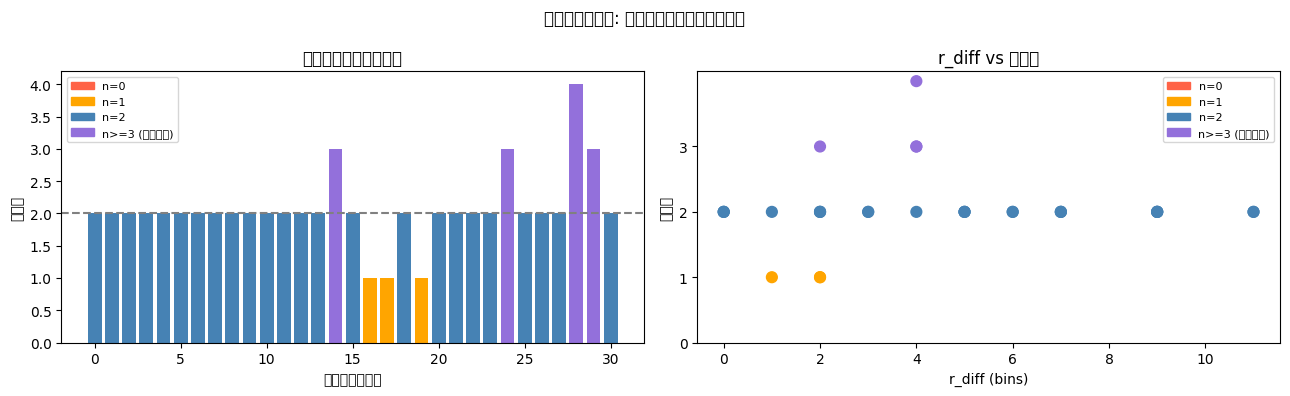

In [192]:
# === シナリオテストデータでの推論 (検出数ベース) ===
import torch, matplotlib.pyplot as plt

SCENARIO_META_CSV = "./learn_dataset_scenario_test/metadata.csv"
scenario_df = pd.read_csv(SCENARIO_META_CSV)
scenario_df = scenario_df[scenario_df["valid_all"] == 1].reset_index(drop=True)
print(f"シナリオテスト: {len(scenario_df)} サンプル")

rows_sc = []
for i in range(len(scenario_df)):
    row = scenario_df.iloc[i]
    npz_path = row["file"]
    if not os.path.isabs(npz_path):
        npz_path = os.path.normpath(os.path.join(".", npz_path))
    x = load_all_rd_maps(npz_path)
    x_tensor = torch.from_numpy(x).unsqueeze(0).float().to(DEVICE)
    with torch.no_grad():
        logits = best_model(x_tensor)
    peaks = decode_peaks_from_logits(logits.cpu())

    cy_r = int(row["cyclist_true_r_idx"]); ve_r = int(row["vehicle_true_r_idx"])
    n = len(peaks)
    cy_min_dr = min(abs(p[1]-cy_r) for p in peaks) if peaks else 999
    ve_min_dr = min(abs(p[1]-ve_r) for p in peaks) if peaks else 999
    # 各ピークのconfidenceリスト
    confs = [round(p[2], 3) for p in peaks]

    rows_sc.append({
        "step":      i,
        "cy_idx":    int(row["source_index_cyclist"]),
        "ve_idx":    int(row["source_index_vehicle"]),
        "r_diff":    abs(cy_r - ve_r),
        "n_peaks":   n,
        "cy_min_dr": cy_min_dr,
        "ve_min_dr": ve_min_dr,
        "confs":     confs,
    })

sc_df = pd.DataFrame(rows_sc)

# --- テーブル出力 ---
print(f"{'step':>5}  {'cy_idx':>7}  {'ve_idx':>7}  {'r_diff':>6}  {'n_peaks':>7}  {'cy_dr':>6}  {'ve_dr':>6}  confs")
print("-" * 75)
for _, r in sc_df.iterrows():
    n_str = f"n={int(r["n_peaks"])}"
    fp_mark = " *FP*" if int(r["n_peaks"]) >= 3 else ""
    print(f"{int(r["step"]):>5}  {int(r["cy_idx"]):>7}  {int(r["ve_idx"]):>7}  "
          f"{int(r["r_diff"]):>6}  {n_str:>7}  {r["cy_min_dr"]:>6.1f}  {r["ve_min_dr"]:>6.1f}  "
          f"{r["confs"]}{fp_mark}")

# --- 集計: n=0/1/2/>=3 を分離 ---
n0  = (sc_df["n_peaks"] == 0).sum()
n1  = (sc_df["n_peaks"] == 1).sum()
n2  = (sc_df["n_peaks"] == 2).sum()
n3p = (sc_df["n_peaks"] >= 3).sum()
total = len(sc_df)
print(f"=== 検出数集計 ===")
print(f"n=0  (全漏れ)  : {n0:>3}/{total} ({n0/total*100:.1f}%)")
print(f"n=1  (片方漏れ): {n1:>3}/{total} ({n1/total*100:.1f}%)")
print(f"n=2  (正常)    : {n2:>3}/{total} ({n2/total*100:.1f}%)")
print(f"n>=3 (誤検出含): {n3p:>3}/{total} ({n3p/total*100:.1f}%)")

# --- グラフ ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("シナリオテスト: 各タイムステップの検出数")

# 左: ステップごとの検出数 (n>=3は赤紫で誤検出を示す)
colors_map = {0: "tomato", 1: "orange", 2: "steelblue"}
bar_colors = ["mediumpurple" if n >= 3 else colors_map.get(n, "steelblue") for n in sc_df["n_peaks"]]
axes[0].bar(sc_df["step"], sc_df["n_peaks"], color=bar_colors)
axes[0].axhline(2, color="gray", linestyle="--", label="期待値 n=2")
axes[0].set_xlabel("タイムステップ"); axes[0].set_ylabel("検出数")
axes[0].set_title("ステップごとの検出数")
from matplotlib.patches import Patch
legend_els = [Patch(color=colors_map[k], label=f"n={k}") for k in [0,1,2]]
legend_els += [Patch(color="mediumpurple", label="n>=3 (誤検出含)")]
axes[0].legend(handles=legend_els, fontsize=8)

# 右: r_diff vs n_peaks の散布図
scatter_colors = ["mediumpurple" if n >= 3 else colors_map.get(n, "steelblue") for n in sc_df["n_peaks"]]
axes[1].scatter(sc_df["r_diff"], sc_df["n_peaks"], c=scatter_colors, s=60, zorder=3)
axes[1].set_xlabel("r_diff (bins)"); axes[1].set_ylabel("検出数")
axes[1].set_title("r_diff vs 検出数")
axes[1].set_yticks([0, 1, 2, 3])
axes[1].legend(handles=legend_els, fontsize=8)

plt.tight_layout()
plt.show()


C:\Users\kousu\AppData\Local\Temp\ipykernel_12084\3590700368.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax0.legend(fontsize=8)
C:\Users\kousu\AppData\Local\Temp\ipykernel_12084\3590700368.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(fontsize=8)
C:\Users\kousu\AppData\Local\Temp\ipykernel_12084\3590700368.py:55: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kousu\AppData\Local\Temp\ipykernel_12084\3590700368.py:55: UserWarning: Glyph 25943 (\N{CJK UNIFIED IDEOGRAPH-6557}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kousu\AppData\Local\Temp\ipykernel_12084\3590700368.py:55: UserWarning: Glyph 12465 (\N{KATAKANA LETTER

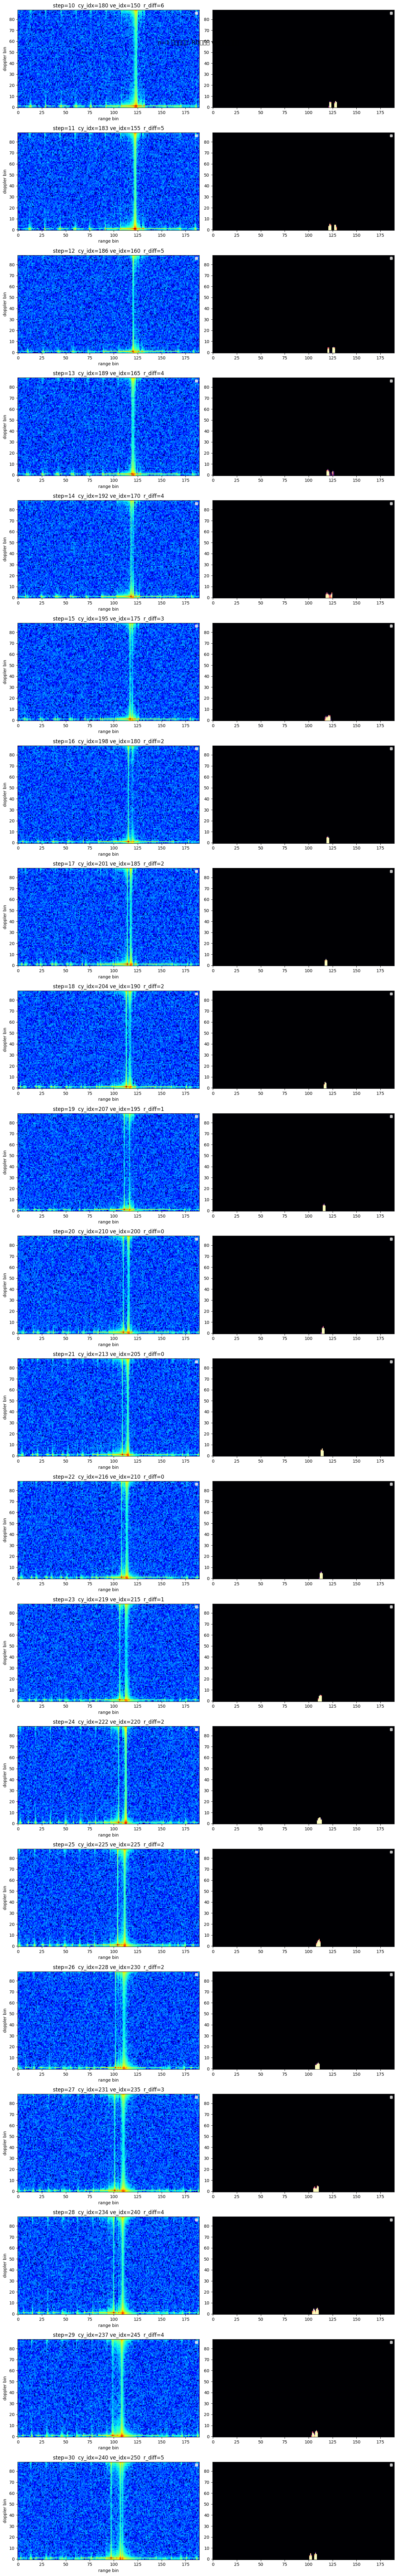

In [198]:
# === n=1 失敗ケース (step 15-19) のRDマップ確認 ===
import torch, matplotlib.pyplot as plt, numpy as np

VMIN, VMAX = -90, -10  # 共通dBスケール
TARGET_STEPS = list(range(10, 31))

scenario_df2 = pd.read_csv("./learn_dataset_scenario_test/metadata.csv")
scenario_df2 = scenario_df2[scenario_df2["valid_all"] == 1].reset_index(drop=True)

fig, axes = plt.subplots(len(TARGET_STEPS), 2, figsize=(13, 4 * len(TARGET_STEPS)))
fig.suptitle("n=1 失敗ケース: RDマップ vs ヒートマップ", fontsize=13)

for row_i, step in enumerate(TARGET_STEPS):
    row = scenario_df2.iloc[step]
    npz_path = os.path.normpath(os.path.join(".", row["file"]))

    # raw dB (正規化なし, center channel)
    raw = np.load(npz_path)["rd_maps"]
    rd_db = 20.0 * np.log10(np.maximum(np.abs(raw[N_FIXED // 2]).astype(np.float32), 1e-12))

    # 推論
    x = load_all_rd_maps(npz_path)
    x_tensor = torch.from_numpy(x).unsqueeze(0).float().to(DEVICE)
    with torch.no_grad():
        logits = best_model(x_tensor)
    heatmap = torch.sigmoid(logits)[0, 0].cpu().numpy()
    peaks = decode_peaks_from_logits(logits.cpu())

    cy_r = int(row["cyclist_true_r_idx"]); cy_d = int(row["cyclist_true_d_idx"])
    ve_r = int(row["vehicle_true_r_idx"]); ve_d = int(row["vehicle_true_d_idx"])
    r_diff = abs(cy_r - ve_r)

    ax0, ax1 = axes[row_i]

    # 左: RDマップ (raw dB, 共通スケール)
    ax0.imshow(rd_db, aspect="auto", origin="lower", cmap="jet", vmin=VMIN, vmax=VMAX)
    #ax0.scatter([cy_r], [cy_d], c="blue",  marker="x", s=150, linewidths=2, label=f"cy r={cy_r}")
    #ax0.scatter([ve_r], [ve_d], c="lime",  marker="x", s=150, linewidths=2, label=f"ve r={ve_r}")
    ax0.set_title(f"step={step}  cy_idx={int(row['source_index_cyclist'])} ve_idx={int(row['source_index_vehicle'])}  r_diff={r_diff}")
    ax0.set_xlabel("range bin"); ax0.set_ylabel("doppler bin")
    ax0.legend(fontsize=8)

    # 右: ヒートマップ
    ax1.imshow(heatmap, aspect="auto", origin="lower", cmap="magma")
    #ax1.scatter([cy_r], [cy_d], c="cyan", marker="x", s=150, linewidths=2, label=f"cy true")
    #ax1.scatter([ve_r], [ve_d], c="lime", marker="x", s=150, linewidths=2, label=f"ve true")
    colors = ["white", "yellow", "orange"]
    #for j, (pk_d, pk_r, pk_c) in enumerate(peaks):
    #    ax1.scatter([pk_r], [pk_d], c=colors[j % len(colors)], marker="o", s=80,
    #                label=f"det{j+1} r={pk_r} conf={pk_c:.2f}")
    #ax1.set_title(f"n_peaks={len(peaks)}")
    #ax1.set_xlabel("range bin"); ax1.set_ylabel("doppler bin")
    ax1.legend(fontsize=8)

plt.tight_layout()
plt.show()
